In [3]:
# !pip install ucimlrepo

In [23]:
# imports
import os
import sys
import pandas as pd
from ucimlrepo import fetch_ucirepo 
import requests
import ssl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

sys.path.append(os.path.abspath(os.path.join('..')))

In [9]:
def load_data(uci_id:int):
    try:
        ssl._create_default_https_context = ssl._create_unverified_context
        data = fetch_ucirepo(id=uci_id)
    except requests.exceptions.ConnectionError:
         print("Error connecting to server. Please check your internet connection and try again.") 

    return data

breast_cancer = load_data(17)
X = breast_cancer.data.features 
y = breast_cancer.data.targets 
  
# print(breast_cancer.metadata) 
# print(breast_cancer.variables)


<Axes: xlabel='Diagnosis'>

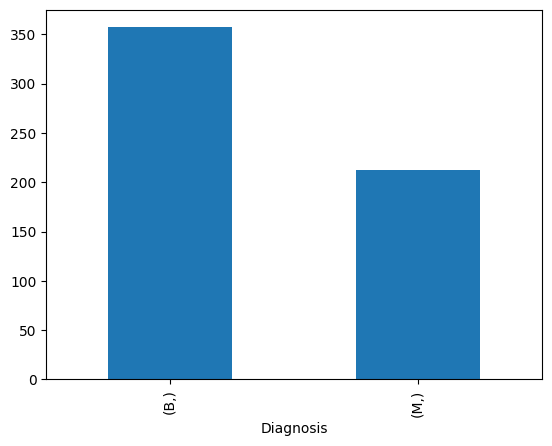

In [7]:
y.value_counts().plot(kind='bar')

In [11]:
any_missing = X.isnull().values.any()
print(f"Missing values > ")

missing_count = X.isnull().sum().sum()
print("Number of missing values in each column:")
print(missing_count)


Missing values > 
Number of missing values in each column:
0


# Data Preprocessing

In [17]:
# scale X
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = y['Diagnosis'].apply(lambda x: 1 if x == 'M' else 0)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=999)

In [ ]:

from logreg import LogisticRegression

logreg = LogisticRegression(epochs=1000, eta=0.01, batch_size=16, algorithm='gd')

ImportError: attempted relative import with no known parent package